# Decision Trees and Scikit-learn

Although, at a theoretical level, is very natural for a decision tree to handle categorical variables, scikit-learn only supports binary splits and numerical variables for now.

https://scikit-learn.org/stable/modules/tree.html#tree-algorithms-id3-c4-5-c5-0-and-cart

# Homework 1, Wine Data set and Decision Trees

Using chemical analysis to determine the origin of wines.
These data are the results of a chemical analysis of wines grown in the same region in Italy but derived from three different cultivars. The analysis determined the quantities of 13 constituents found in each of the three types of wines. 

In [ ]:
import matplotlib.pyplot as plt
from sklearn import metrics, datasets, tree
from sklearn.model_selection import train_test_split

# 1. load 
wine = datasets.load_wine()
X, y = wine.data, wine.target

# partition data with train_test_spli

#trian_size, sratify

value=0.1
gn=42

#with stratify
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=value,stratify=y,random_state=gn)

#without stratify
X_train_no_stratify, X_test_no_stratify, y_train_no_stratify, y_test_no_stratify = train_test_split(X, y, train_size=value,random_state=gn)

#radom_state: Controls the shuffling applied to the data before applying the split. 
#Pass an int for reproducible output across multiple function calls
#Popular integer random seeds are 0 and 42

print("train size:",len(X_train),"\ntest size:",len(X_test))

train size: 17 
test size: 161
train size: 17 
test size: 161


Define the classifier, in scikit-learnrequires $always$ numerical values

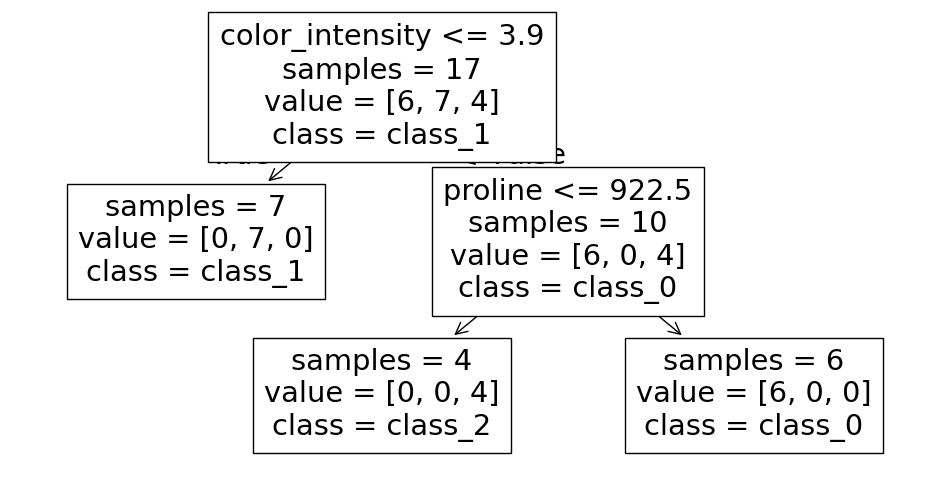

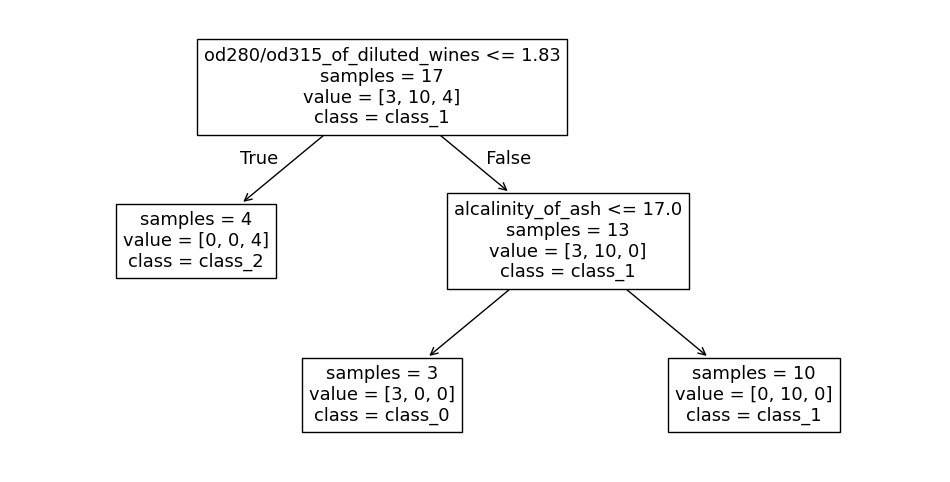

In [42]:
# 2. learn classifier

#with stratify
predictor = tree.DecisionTreeClassifier(criterion='entropy',random_state=gn)
predictor.fit(X_train, y_train)

#without stratify
predictor_no_stratify = tree.DecisionTreeClassifier(criterion='entropy',random_state=gn)
predictor_no_stratify.fit(X_train_no_stratify, y_train_no_stratify)

# 3. plot classifier

#with stratify
figure = plt.figure(figsize=(12, 6))
tree.plot_tree(predictor, feature_names=wine.feature_names, class_names=wine.target_names, impurity=False)
plt.show()

#without stratify
figure_no_stratify = plt.figure(figsize=(12, 6))
tree.plot_tree(predictor_no_stratify, feature_names=wine.feature_names, class_names=wine.target_names, impurity=False)
plt.show()

In [43]:
# 4. test classifier

#with stratify
print("With stratify")
y_pred = predictor.predict(X_test)
print("accuracy on testing set:",  round(metrics.accuracy_score(y_test,y_pred),2))
print("depth:",predictor.get_depth())
print("number of leaves:",predictor.get_n_leaves())

print("-----------------------")

#without stratify
print("Without stratify")
y_pred_no_stratify = predictor_no_stratify.predict(X_test_no_stratify)
print("accuracy on testing set:",  round(metrics.accuracy_score(y_test_no_stratify,y_pred_no_stratify),2))
print("depth:",predictor_no_stratify.get_depth())
print("number of leaves:",predictor_no_stratify.get_n_leaves())

With stratify
accuracy on testing set: 0.83
depth: 2
number of leaves: 3
-----------------------
Without stratify
accuracy on testing set: 0.69
depth: 2
number of leaves: 3
